# Deliverable 2 — Bayesian Inference (UB)
## Resumen: prior logístico jerárquico + posterior MCMC + propuesta de misión

Este notebook resume el trabajo entregado. Para detalle pedagógico ver los notebooks 01–04. Todo el código está en [`../modeling/`](../modeling/), [`../simulator/`](../simulator/), [`../strategies/`](../strategies/).

## Decisiones de modelado en una página

**Prior** (Task 1). $\pi_j(\beta, \tau) = \text{softmax}_j(\eta_j)$ con
$$\eta_j = \beta_0 + \beta_1 d_\text{long}(j;\tau) + \beta_2 d_\text{trans}(j;\tau) - \beta_3 d_\text{long}^2(j;\tau) - \beta_4 d_\text{trans}^2(j;\tau).$$

Donde $d_\text{long}, d_\text{trans}$ son distancias proyectadas al punto esperado $\mu(\tau_\text{fall}, \tau_\text{drift}) = x_E + \tau_\text{fall}(v_\text{plane} + 0.5 v_\text{wind}) + \tau_\text{drift} v_\text{drift}$. Las dos $\tau$ y los cinco $\beta$ son Bayesianos.

**Detección** (Task 2). $\rho_j = 1 - \exp(-\lambda_0 (1-d_j)^{a_d}(1-r_j)^{a_r} \cdot e)$ (saturante exponencial) con $\lambda_0=1.2, a_d=1.0, a_r=0.6$ — calibrado cualitativamente con previous_missions_reports.

**Posterior** (Task 3). MCMC NUTS marginalizando $Z$:
$$\log P(s_t \mid \beta, \tau) = \log \sum_{j \in R_t} \pi_j \rho_j^{s_t} (1 - \rho_j)^{1-s_t}.$$

Posterior sobre celdas: $P(Z=j \mid s_{1:T}) = \mathbb{E}_{\beta,\tau \sim \text{post}}[\pi_j L_j / \sum_k \pi_k L_k]$.

**Próxima misión** (Task 4). **Funnel HDR**: con la posterior actual $P(Z)$,
1. Definir el conjunto $\mathcal{H}_\alpha$ de credibilidad $\alpha$ (cells que acumulan $\alpha$ de masa, ordenadas).
2. Computar score $P(Z=j) \cdot \rho_j(e)$ restringido a $\mathcal{H}_\alpha$.
3. Top-$K$ celdas → rectángulo mínimo que las contiene. El effort se elige maximizando $\sum_{j \in R} P(Z=j)\rho_j(e) / (e\cdot|R|)$.


In [1]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

from update_version.simulator.grid import load_grid
from update_version.simulator.environment import MissionRecord
from update_version.modeling.detection import DETECTORS
from update_version.modeling.priors_logistic import PRIORS
from update_version.modeling.pymc_model import run_mcmc, diagnostics_summary
from update_version.modeling.posterior import posterior_over_Z, summarise_posterior_over_Z
from update_version.strategies.next_mission import (
    propose_via_hdr_topk, hdr_mask, hdr_cells, hdr_bounding_box,
)

grid = load_grid('../data/grid_dataset.csv')
spec = PRIORS['P6_mixed_wit_informative']
detector = DETECTORS['D1_saturating_exponential']
BUDGET = 230.0
TEAM_ID = 'TEAM_XX'  # cambiar al ID asignado por el profesor
print(f'Prior: {spec.name}  |  Detector: {detector.name}  |  Budget: {BUDGET}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/josecalatayud/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.star

AttributeError: _ARRAY_API not found

Prior: P6_mixed_wit_informative  |  Detector: saturating_exponential  |  Budget: 230.0


## Task 1 — Prior heatmap

Mostramos el prior predictivo $\mathbb{E}_{\beta,\tau \sim \text{prior}}[\pi_j]$ del modelo escogido.

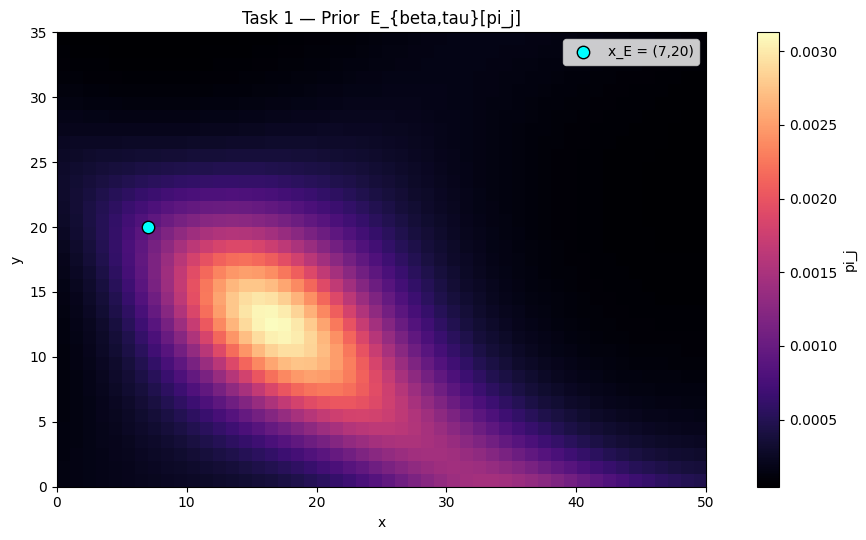

In [2]:
prior_pi = spec.prior_predictive_pi(grid.x, grid.y, n_samples=1500, seed=0)
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(grid.reshape_2d(prior_pi), origin='lower', cmap='magma',
                extent=[0, grid.Nx, 0, grid.Ny])
ax.scatter(7, 20, color='cyan', s=80, marker='o', edgecolor='black', label='x_E = (7,20)')
ax.set_title('Task 1 — Prior  E_{beta,tau}[pi_j]'); ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); plt.colorbar(im, ax=ax, fraction=0.046, label='pi_j')
plt.tight_layout(); plt.show()

## Task 2 — Detection model heatmap

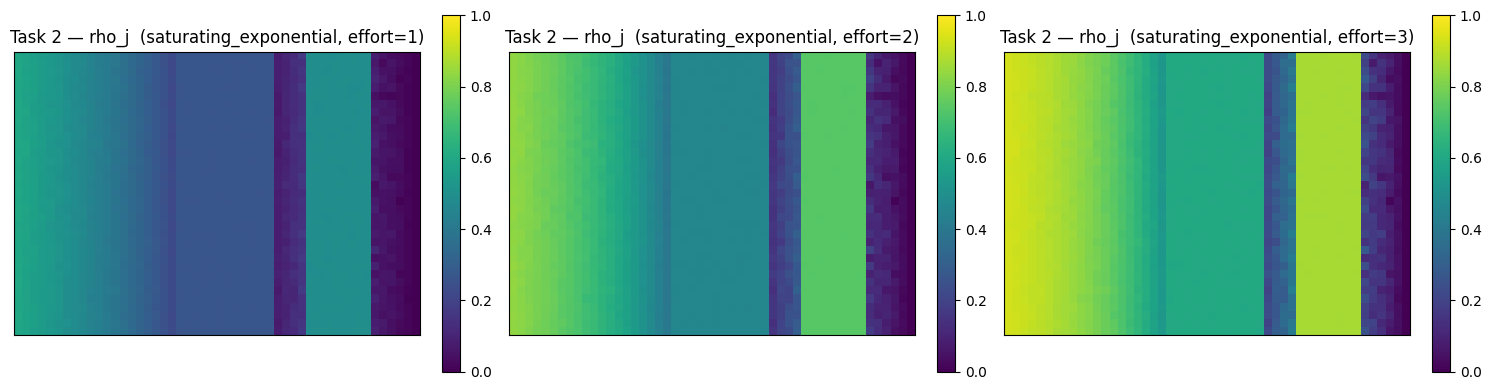

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, e in zip(axes, [1, 2, 3]):
    rho = detector.rho(grid.depth, grid.roughness, e)
    im = ax.imshow(grid.reshape_2d(rho), origin='lower', cmap='viridis', vmin=0, vmax=1,
                   extent=[0, grid.Nx, 0, grid.Ny])
    ax.set_title(f'Task 2 — rho_j  ({detector.name}, effort={e})'); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Task 3 — Posterior tras las misiones observadas

**Para reproducir con misiones reales:** rellena `OBSERVED_MISSIONS` con los outcomes que has leído del webapp. Cada `MissionRecord` necesita los seis campos input + `s_t`. (Si todavía no has hecho misiones, deja la lista vacía para mostrar el prior.)

In [4]:
OBSERVED_MISSIONS: list[MissionRecord] = [
    # Ejemplo (a borrar y sustituir por misiones reales):
    # MissionRecord(mission_id=1, x_min=10.5, x_max=15.5, y_min=10.5, y_max=15.5,
    #               effort=2, n_cells=36, cost=72.0, s_t=0, budget_remaining=158.0),
]

idata = run_mcmc(spec, detector, OBSERVED_MISSIONS, grid,
                  draws=1000, tune=1000, chains=4, cores=1,
                  progressbar=False, use_cache=True)
print('Diagnostics:')
print(diagnostics_summary(idata).to_string())

Diagnostics:
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
b0        -0.040  4.884  -9.370    9.288      0.135    0.133  1321.164   930.609  1.003
b1         0.098  0.103  -0.093    0.284      0.003    0.004  1383.923   937.972  1.001
b2         0.071  0.105  -0.138    0.266      0.003    0.003  1739.262   943.304  1.002
b3         0.011  0.008   0.000    0.025      0.000    0.000   925.774   600.361  0.999
b4         0.025  0.018   0.000    0.056      0.001    0.000   663.173   330.119  1.002
tau_fall   1.031  0.317   0.513    1.588      0.009    0.012  1248.434   720.417  1.006
tau_drift  1.050  0.327   0.481    1.631      0.010    0.012  1093.944   664.926  1.007


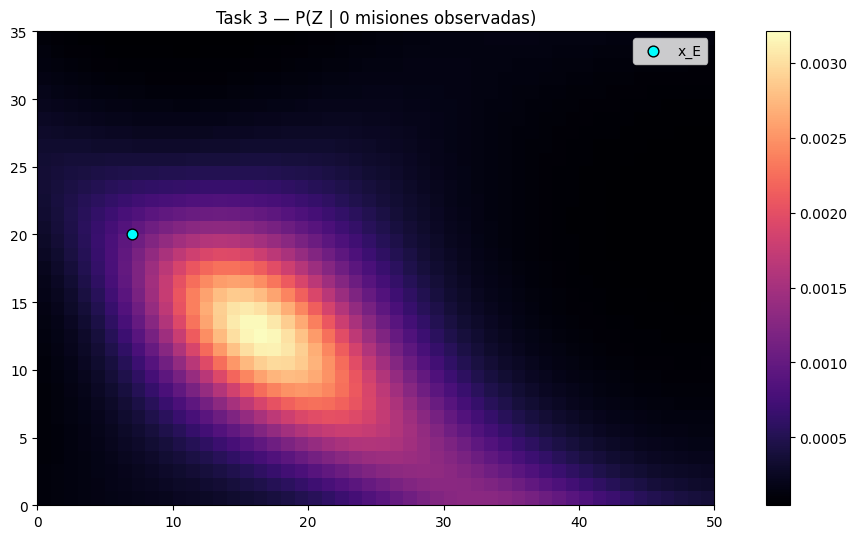

argmax cell 616 (x,y)=(16.5, 12.5), max P=0.003, entropy=6.91 nats


In [5]:
p_Z = posterior_over_Z(idata, grid, detector, OBSERVED_MISSIONS)
fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(grid.reshape_2d(p_Z), origin='lower', cmap='magma', extent=[0, grid.Nx, 0, grid.Ny])
for m in OBSERVED_MISSIONS:
    edge = 'lime' if m.s_t == 1 else 'cyan'
    r = plt.Rectangle((m.x_min, m.y_min), m.x_max-m.x_min, m.y_max-m.y_min,
                       edgecolor=edge, facecolor='none', lw=1.5)
    ax.add_patch(r)
ax.scatter(7, 20, color='cyan', s=60, marker='o', edgecolor='black', label='x_E')
ax.set_title(f'Task 3 — P(Z | {len(OBSERVED_MISSIONS)} misiones observadas)')
ax.legend(); plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

summ = summarise_posterior_over_Z(p_Z, grid)
print(f'argmax cell {summ["argmax_cell"]} (x,y)={summ["argmax_xy"]}, '
      f'max P={summ["max_prob"]:.3f}, entropy={summ["entropy_nats"]:.2f} nats')

## Task 4 — Próxima misión propuesta (Funnel HDR)

Aplicamos el funnel de tres etapas sobre la posterior actual:

1. **HDR multi-nivel** (50% / 80% / 95%) — contexto visual de la zona plausible.
2. **Bounding box del HDR de trabajo** (default 80%) + **score** $P(Z) \cdot \rho_j(e)$ dentro.
3. **Top-K celdas** → **rectángulo mínimo** que las contiene. El effort se elige maximizando expected detection / coste.

Esto evita explorar todo el grid (peor decisión informacionalmente y peor uso del budget).

Budget usado: 0/230, restante: 230
HDR 50%:  253 cells (14.5%), bbox x=8.5..33.5, y=0.5..20.5
HDR 80%:  628 cells (35.9%), bbox x=2.5..45.5, y=0.5..24.5
HDR 95%: 1205 cells (68.9%), bbox x=0.5..49.5, y=0.5..34.5

Propuesta T+1 (HDR=0.8, top_k=20):
  rect:  x in [11.5, 16.5], y in [11.5, 15.5]
  effort = 1, n_cells = 30, cost = 30.0
  expected_detection in R = 0.0290
  HDR mass capturada por R = 0.0828


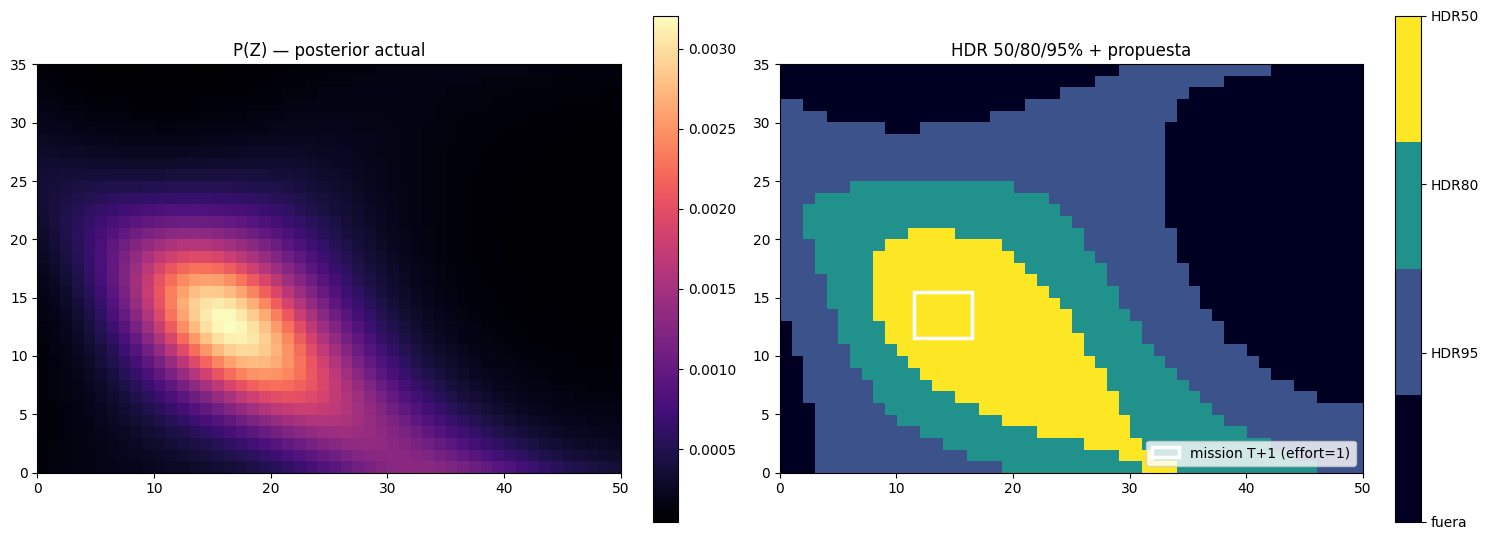

In [6]:
from matplotlib.colors import ListedColormap

budget_used = sum(m.cost for m in OBSERVED_MISSIONS)
budget_remaining = BUDGET - budget_used
print(f'Budget usado: {budget_used:.0f}/{BUDGET:.0f}, restante: {budget_remaining:.0f}')

# Etapa 1: HDR multi-nivel sobre la posterior actual
levels = [0.50, 0.80, 0.95]
masks = {a: hdr_mask(p_Z, a) for a in levels}
for a in levels:
    bb = hdr_bounding_box(p_Z, grid, a)
    print(f'HDR {int(a*100)}%: {int(masks[a].sum()):4d} cells '
          f'({100*masks[a].sum()/grid.n_cells:.1f}%), bbox x={bb[0]+0.5}..{bb[1]+0.5}, y={bb[2]+0.5}..{bb[3]+0.5}')

# Etapa 2+3: propose_via_hdr_topk
ALPHA_WORK = 0.80
TOP_K = 20
proposal = propose_via_hdr_topk(p_Z, grid, detector, budget_remaining,
                                  hdr_mass=ALPHA_WORK, top_k=TOP_K)
print(f'\nPropuesta T+1 (HDR={ALPHA_WORK}, top_k={TOP_K}):')
print(f'  rect:  x in [{proposal.x_min}, {proposal.x_max}], y in [{proposal.y_min}, {proposal.y_max}]')
print(f'  effort = {proposal.effort}, n_cells = {proposal.n_cells}, cost = {proposal.cost}')
print(f'  expected_detection in R = {proposal.expected_detection:.4f}')
print(f'  HDR mass capturada por R = {proposal.hdr_mass_captured:.4f}')

# Visualización funnel: HDR multi-nivel + rect propuesto
layer = np.zeros_like(p_Z, dtype=int)
layer[masks[0.95]] = 1; layer[masks[0.80]] = 2; layer[masks[0.50]] = 3
cmap_hdr = ListedColormap(['#000022', '#3b528b', '#21918c', '#fde725'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
im0 = axes[0].imshow(grid.reshape_2d(p_Z), origin='lower', cmap='magma',
                      extent=[0, grid.Nx, 0, grid.Ny])
axes[0].set_title('P(Z) — posterior actual')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(grid.reshape_2d(layer), origin='lower', cmap=cmap_hdr,
                      extent=[0, grid.Nx, 0, grid.Ny], vmin=0, vmax=3)
r = plt.Rectangle((proposal.x_min, proposal.y_min),
                   proposal.x_max-proposal.x_min, proposal.y_max-proposal.y_min,
                   edgecolor='white', facecolor='none', lw=2.5,
                   label=f'mission T+1 (effort={proposal.effort})')
axes[1].add_patch(r); axes[1].legend(loc='lower right')
axes[1].set_title(f'HDR 50/80/95% + propuesta')
cbar = plt.colorbar(im1, ax=axes[1], fraction=0.046, ticks=[0,1,2,3])
cbar.set_ticklabels(['fuera','HDR95','HDR80','HDR50'])
plt.tight_layout(); plt.show()

## Task 5 — Discusión

**Fortalezas.**
1. *Jerarquía Bayesiana*: el prior sobre celdas no es fijo — los coeficientes $\beta$ y $\tau$ tienen su propia posterior, de modo que la incertidumbre física se propaga correctamente al heatmap de $P(Z)$.
2. *Modularidad*: cuatro detectores intercambiables y ocho priors pre-definidos permiten estudiar sensibilidad sin tocar la pipeline. Comparación Monte Carlo en `experiments/compare_priors.py`.
3. *Marginalización analítica de Z*: gracias a $q_{t,j} = c_{t,j}\rho_{t,j}$, el log-likelihood se reduce a una suma sobre celdas cubiertas — escala muy bien a histories largas (NUTS sigue siendo eficiente).
4. *Trazabilidad de diagnósticos*: $\hat R$, ESS y traceplots por parámetro están disponibles vía arviz.

**Limitaciones / asunciones.**
1. El acoplamiento del viento durante la caída $\alpha_\text{wind}=0.5$ es fijo (no Bayesiano).
2. Los parámetros del detector son fijos: solo el prior sobre $Z$ es jerárquico. Si los reports de previous_missions están sesgados, nuestro $\rho$ podría no calibrar la verdad-de-terreno.
3. Asumimos independencia condicional de outcomes de misiones dado $Z$. Si el sensor tuviera correlación temporal (aprendizaje del operario, cambios meteorológicos), violamos esto.
4. Estrategia greedy por etapa (myopic): maximiza beneficio inmediato, no busca la secuencia óptima multi-paso (que sería un POMDP).

**Mejoras con más información.**
1. Pasar a un detector jerárquico también (priors sobre $\lambda_0, a_d, a_r$).
2. Implementar `propose_info_gain` (reducción de entropía esperada / coste) para alternativa no-myope.
3. Bayes Factor entre los 4 detectores con misiones reales.
4. Modelar $\alpha_\text{wind}$ y posibles correlaciones espaciales en $\rho$ (efectos de borde de barco, cobertura imperfecta dentro de R).

## Generar `missions.csv` para la entrega

In [7]:
missions_df = pd.DataFrame([{
    'team_id': TEAM_ID,
    'mission_id': m.mission_id,
    'x_min': m.x_min, 'x_max': m.x_max,
    'y_min': m.y_min, 'y_max': m.y_max,
    'effort': m.effort, 'n_cells': m.n_cells, 'cost': m.cost,
    's_t': m.s_t, 'budget_remaining': m.budget_remaining,
    'timestamp': m.timestamp,
} for m in OBSERVED_MISSIONS])
missions_df.to_csv('../results/missions.csv', index=False)
missions_df

""
